# Simulations: the equality study across four uncertainty levels

Runs the Beta-agent (Bayesian) bandit simulations on the **PUD**, **Tobacco** and
**Ego depletion** networks at different levels of problem uncertainty by creating network variants that vary equality and hold other network features (roughly) fixed (density, clustering).

Uncertainty is the problem easiness — the gap between the two
theories' success rates. It is the one parameter that varies across the four studies;
everything else is held fixed.

## The design

The design is **nested**. Rather than one simulation per parameter draw, each
(network, arm) cell builds `N_VARIANTS` distinct network variants and simulates each one
`N_RUNS` times under different seeds. Replicates of a variant share every parameter and
differ only in their simulation seed.

All machinery lives in `model/equality_study.py`.

## How this notebook is organised

- **Setup** defines methods and *nothing else* — no variable is assigned and nothing is
  executed. Skip it on a first read.
- **Simulations** is the core part: configuration, the networks, then one
  section per uncertainty level.

## Running across sessions

A full run does not fit in one Colab session. `ACCUMULATE = True` (the default) makes
that a non-event: every variant is checkpointed to its own shard as it finishes, and a
later session skips what is already on disk. Reconnect, re-run, and it picks up where it
stopped. The four study cells are independent, so they can also be run on four different
machines.

## Running as a script

```bash
jupyter nbconvert --to script "2. Simulations Equality - Uncertainty Sweep.ipynb"
ipython "2. Simulations Equality - Uncertainty Sweep.py"
```

Every cell that *executes* something is wrapped in `if __name__ == "__main__":` for this approach. Without the guard the script would spawn workers, each of which worker would re-run the whole notebook — reloading the networks, flooding the log, and re-launching all four studies.

# Setup

## Imports

In [1]:
import multiprocessing
import os
import pickle
import shutil
import subprocess
import sys
import time
from multiprocessing import cpu_count
from pathlib import Path

import networkx as nx
import pandas as pd

from IPython.display import display

## Environment

In [2]:
def bootstrap(running_locally):
    """Make the repo importable and the working directory, and return its root.

    On Colab the repo does not exist yet, so it is force-cloned; locally we walk up
    from wherever the kernel started to the directory holding `model/`, which is what
    a FileNotFoundError on `networks/citation_data/...` usually actually means.

    Uses subprocess/os.chdir rather than !/% magics so the `running_locally` guard
    actually holds — a line magic fires regardless of the surrounding `if`.
    """
    # Under the `spawn` start method this module is re-imported in every worker, so
    # bootstrap() runs there too. A worker still needs the cwd and sys.path — that is
    # how it imports `model` to unpickle its job — but it must NEVER re-clone: that
    # would delete the repo out from under the run in progress.
    #
    # spawn re-imports the main module under the name `__mp_main__`, which is the
    # discriminator to use here. `multiprocessing.parent_process()` is not: it is
    # still None during the re-import, since the child sets it only afterwards.
    is_worker = __name__ != "__main__" or multiprocessing.parent_process() is not None

    if not running_locally and not is_worker:
        # Anchor on an absolute base, never the cwd: resolving the repo name relative
        # to the cwd makes a second run clone INSIDE the first clone.
        colab_base = Path('/content')
        os.chdir(colab_base)
        repo_dir = colab_base / 'e_network_inequality'
        if repo_dir.exists():
            shutil.rmtree(repo_dir)
        subprocess.run(['git', 'clone', '-b', 'main',
                        'https://github.com/IgnacioOQ/e_network_inequality'], check=True)
        subprocess.run(['pip', 'install', '-q', 'dill'], check=True)
        os.chdir(repo_dir)
    else:
        start = Path('/content/e_network_inequality') if not running_locally else Path.cwd()
        repo_dir = start
        while repo_dir != repo_dir.parent and not (repo_dir / 'model').is_dir():
            repo_dir = repo_dir.parent
        os.chdir(repo_dir)

    root = Path.cwd()
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    if not is_worker:
        print("Working dir:", root)
    return root

## Paths

In [3]:
def study_paths(option_slug, run_tag, running_locally):
    """Where one study's output lives: ``(results_dir, variant_cache_dir)``.

    Both are created. Slug and run tier are separate path components, so no two
    configurations can share shards, and a smoke run can never overwrite a full one.

    The variant cache is deliberately not under the results tree and never on the
    Drive mount. It is a pure function of the variation seeds, so losing it costs a
    rebuild and nothing else — and it is written once and read once per variant,
    which is the access pattern a network mount handles worst.
    """
    if running_locally:
        results_root = Path('results/equality_study')
        cache_root = Path('.variant_cache')
    else:
        from google.colab import drive
        drive.mount('/content/drive')      # idempotent; safe once per study
        results_root = Path('/content/drive/My Drive/Colab Projects/Data Driven ABMs/'
                            'Data Sets/equality_study')
        cache_root = Path('/content/variant_cache')

    results_dir = results_root / option_slug / run_tag
    cache_dir = cache_root / option_slug / run_tag
    results_dir.mkdir(parents=True, exist_ok=True)
    cache_dir.mkdir(parents=True, exist_ok=True)
    return results_dir, cache_dir


def save_csv(df, directory, name):
    """Write one CSV beside the shards, and say where it went."""
    path = Path(directory) / name
    df.to_csv(path, index=False)
    print(f"  Saved: {path} ({len(df)} rows)")
    return path

## Networks

In [4]:
def load_indexed(path):
    """Load a pickled citation network, relabelled to contiguous integer indices.

    The vectorized model indexes its adjacency matrix positionally, so node labels
    must be 0..n-1.
    """
    path = Path(path)
    with open(path, 'rb') as f:
        G = pickle.load(f)
    G = nx.relabel_nodes(G, {n: i for i, n in enumerate(G.nodes())})
    assert not list(nx.selfloop_edges(G)), f"self-loops present in {path}"
    print(f"  {path.name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
          f"avg clustering {nx.average_clustering(G):.5f}")
    return G


def load_networks(labels=('pud', 'tobacco', 'ego'),
                  citation_data='./networks/citation_data'):
    """The empirical citation networks, as ``(label, graph)`` pairs."""
    citation_data = Path(citation_data)
    print("Loading networks:")
    return [(label, load_indexed(citation_data / f'{label}_network.pkl'))
            for label in labels]


def baseline_statistics(networks):
    """Baseline structure of each unmodified network.

    The reference point every variant's equality and clustering statistics are read
    against.
    """
    # Deferred: on Colab utils/ arrives with the clone, and Setup runs nothing.
    from utils.network_utils import network_statistics

    return pd.DataFrame([
        {'network': label,
         'n_nodes': G.number_of_nodes(),
         'n_edges': G.number_of_edges(),
         **{k: float(v) for k, v in network_statistics(G).items()}}
        for label, G in networks
    ])

## The simulation pipeline

One function for one study, from the configuration check through to the saved
per-variant summaries.

It takes no notebook globals: every parameter is an argument, so it behaves identically
called from a cell, from the converted script, or from a test.

In [5]:
def run_uncertainty_study(
    *,
    # What makes this study this study — set in its call cell below.
    option_slug,
    option_title,
    uncertainty,
    master_seed,
    # Shared across the sweep — supplied by FIXED.
    networks,
    running_locally,
    run_tag,
    smoke,
    accumulate,
    num_cores,
    methods,
    n_variants,
    n_runs,
    n_experiments,
    max_steps,
    cs_window,
    cs_min_steps,
    proportion_edges_max,
    # Per-session overrides.
    variant_slice=None,
    plots=True,
):
    """Run the whole pipeline for one uncertainty level.

    Phase A builds every network variant in parallel and caches it; phase B simulates
    each cached variant `n_runs` times, checkpointing one shard per variant. Both
    phases are resumable — re-calling this skips whatever is already on disk, so an
    interrupted session costs at most the variant in flight.

    `variant_slice` restricts this session to ``range(start, stop)`` of the variant
    indices, so several machines can divide one arm without coordinating.

    Returns a dict of the tables produced. Each is also saved beside the shards, so
    the record survives the runtime being released.
    """
    # Deferred: on Colab this module arrives with the clone bootstrap() performs,
    # and the Setup section that defines this function deliberately runs nothing.
    from model.equality_study import (
        arm_dir,
        build_variants,
        check_fingerprint,
        check_variance,
        parameter_coverage,
        plot_variant_summary,
        project_runtime,
        run_study,
        study_report,
        summarise_arm,
    )

    methods = list(methods)
    results_dir, cache_dir = study_paths(option_slug, run_tag, running_locally)
    n_arms = len(networks) * len(methods)

    print(f"\n{'=' * 78}")
    print(f"{option_title}   [{option_slug}]")
    print('=' * 78)
    print(f"  uncertainty={uncertainty}  window={cs_window:,}  "
          f"max_steps={max_steps:,}  master_seed={master_seed}")
    print(f"  {n_variants:,} variants x {n_runs:,} runs x {n_arms} arms "
          f"= {n_variants * n_runs * n_arms:,} model runs")
    print(f"  Results: {results_dir}")
    print(f"  Cache:   {cache_dir}")

    # ── Reconcile this session's configuration with the study already on disk ──
    # Identity keys (uncertainty, master_seed, max_steps, window, n_runs, smoke, ...)
    # must match what was stamped: a mismatch means these are two different studies,
    # and merging them would build the summaries from one run's data under the
    # other's label. A conflict RAISES and deletes nothing. Extent keys (n_variants,
    # methods) may GROW, which is what makes a multi-session run work.
    config = dict(
        option=option_slug,
        master_seed=master_seed,
        smoke=bool(smoke),
        uncertainty=uncertainty,
        n_experiments=n_experiments,
        max_steps=max_steps,
        window=cs_window,
        min_steps=cs_min_steps,
        n_variants=n_variants,
        n_runs=n_runs,
        proportion_edges_max=proportion_edges_max,
        methods=methods,
        skip_arms=[],
    )
    check_fingerprint(results_dir, config, accumulate=accumulate)

    sim_kwargs = dict(
        tolerance_stopping=False,
        choice_stability_stopping=True,
        choice_stability_window=cs_window,
        choice_stability_min_steps=cs_min_steps,
        record_choice_flips=False,
        number_of_steps=max_steps,
        show_bar=False,
        agent_type='beta',
    )

    # Packed once, so the two phases cannot enumerate the (network, arm, variant)
    # grid differently. See docs/PARALLELIZATION_PLAN.md.
    study_kwargs = dict(
        methods=methods,
        skip=[],
        master_seed=master_seed,
        n_variants=n_variants,
        n_runs=n_runs,
        uncertainty=uncertainty,
        n_experiments=n_experiments,
        sim_kwargs=sim_kwargs,
        num_cores=num_cores,
        variant_slice=variant_slice,
        build_kwargs=dict(proportion_edges_max=proportion_edges_max),
    )

    # ── Phase A — build and cache every variant ───────────────────────────────
    # Variant generation is single-threaded, so building inline would leave
    # num_cores - 1 cores idle. Doing it up front saturates them and the replicate
    # loop never waits on a build.
    print("\nPhase A — building variants")
    t0 = time.perf_counter()
    build_cost = build_variants(networks, cache_dir, **study_kwargs)
    build_sec = time.perf_counter() - t0
    if len(build_cost):
        print(f"  built {len(build_cost)} variants in {build_sec:,.0f}s "
              f"({build_cost['build_sec'].mean():.2f}s each)")
    else:
        print("  every requested variant already cached")

    # ── Phase B — simulate each cached variant ────────────────────────────────
    # The variant is handed to the worker pool once via its initializer rather than
    # riding in every job's parameter dict — at 500 replicates that is the difference
    # between pickling the graph once per worker and once per run. Interrupting loses
    # at most the variant in flight.
    print("\nPhase B — running simulations")
    t0 = time.perf_counter()
    cost = run_study(networks, results_dir, variant_cache_root=cache_dir, **study_kwargs)
    run_sec = time.perf_counter() - t0
    print(f"  phase B took {run_sec:,.0f}s")
    if len(cost):
        save_csv(cost, results_dir, 'cost_all_arms.csv')

    # ── Where the study stands, re-read from disk ─────────────────────────────
    # From disk rather than from what the run believed it wrote, so the record
    # reflects what actually landed.
    print("\nProgress")
    report = study_report(results_dir, networks, methods, n_variants, n_runs)
    if len(report):
        save_csv(report, results_dir, 'progress_report.csv')

    coverage = parameter_coverage(
        results_dir, networks, methods, n_variants,
        master_seed=master_seed,
        uncertainty=uncertainty,
        n_runs=n_runs,
        proportion_edges_max=proportion_edges_max,
    )
    if len(coverage):
        save_csv(coverage, results_dir, 'parameter_coverage.csv')

    # ── Validation — seeding and variance ─────────────────────────────────────
    # For every variant: are its replicate seeds distinct, and does at least one
    # outcome vary across them? A variant whose replicates are identical is the
    # signature of the fork-inherited-RNG bug — every worker drawing the same
    # stream. It presents as unanimous agreement and zero variance rather than as a
    # crash, which is why it needs an explicit check rather than trust.
    print("\nValidation")
    frames = []
    for label, _ in networks:
        for method in methods:
            rep = check_variance(arm_dir(results_dir, label, method))
            if len(rep):
                rep.insert(0, 'method', method)
                rep.insert(0, 'network', label)
                frames.append(rep)
    variance = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if len(variance):
        save_csv(variance, results_dir, 'variance_check.csv')
        n_bad = int((~variance['seeds_distinct']).sum()
                    + (~variance['any_variance']).sum())
        print(f"  {'PASS' if n_bad == 0 else 'FAIL'} — {n_bad} problem variant(s) "
              f"of {len(variance)} checked")
    else:
        print("  no shards yet — nothing to check")

    # ── Per-variant summaries — the analysis-facing table ─────────────────────
    # A finished study holds well over a million replicate rows but only a few
    # thousand variant rows, and the variant is the unit at which the equality
    # covariates actually vary. Reading the shards is the one expensive operation
    # here, so it happens once and every output form is written from the result.
    frames = []
    for label, _ in networks:
        for method in methods:
            s = summarise_arm(arm_dir(results_dir, label, method))
            if len(s):
                frames.append(s)
    summary = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    if len(summary):
        save_csv(summary, results_dir, 'variant_summary.csv')
        # One CSV per network beside the combined table, sliced from the same frame
        # so they cannot drift from it. A network with no shards is skipped rather
        # than written empty, which keeps a partial study readable: a missing file
        # means "not started", not "zero results".
        for label, _ in networks:
            sub = summary[summary['network'] == label]
            if len(sub):
                save_csv(sub, results_dir, f'variant_summary_{label}.csv')

    # One point per variant: its mean outcome against each structural predictor.
    if plots and len(summary):
        for label, _ in networks:
            for method in methods:
                sub = summary[(summary['network'] == label)
                              & (summary['method'] == method)]
                if len(sub):
                    plot_variant_summary(
                        sub,
                        title=f"{option_title} — {label} / {method}",
                        save_path=results_dir / f"{label}_{method}_scatter.png",
                    )

    # Extrapolates remaining wall-clock from the variants completed so far. At full
    # scale this is the number that decides whether to partition an arm across
    # machines with variant_slice.
    projection = project_runtime(cost, n_variants, n_runs) if len(cost) else pd.DataFrame()
    if len(projection):
        save_csv(projection, results_dir, 'runtime_projection.csv')

    return dict(
        slug=option_slug,
        title=option_title,
        uncertainty=uncertainty,
        master_seed=master_seed,
        results_dir=results_dir,
        cache_dir=cache_dir,
        build_cost=build_cost,
        cost=cost,
        report=report,
        coverage=coverage,
        variance=variance,
        summary=summary,
        projection=projection,
        build_sec=build_sec,
        run_sec=run_sec,
    )

# Simulations

## Configuration

In [ ]:
# ── Master parameters ────────────────────────────────────────────────────────
RUNNING_LOCALLY = True   # False → Colab: force-fresh clone, pip install, mount Drive.
                         # True  → laptop or cluster node, run from the repo clone.
SMOKE_TEST      = True   # True  → tiny grid. Proves the plumbing — shard writes,
                         #         resume, the variance check — and measures NOTHING.
                         #         Smoke and full write to separate directories and
                         #         carry different fingerprints, so they can never be
                         #         merged; do not analyse a 'smoke' tree.
ACCUMULATE      = True   # True  → ADD to what earlier sessions banked; variants
                         #         already on disk are skipped, so re-running after a
                         #         disconnect resumes rather than restarting. Raising
                         #         N_VARIANTS between sessions GROWS the study, and
                         #         the earlier variants stay bit-identical.
                         # False → start clean: DELETE this study's RUN_TAG subtree.
                         #         The only path that discards data.
MAX_CORES       = 60      # Ceiling on worker processes. Each worker holds its own copy
                         # of the network plus simulation state, so memory rather than
                         # CPU is usually the binding constraint.

# ── Fixed simulation parameters — identical across all four studies ──────────
N_EXPERIMENTS         = 1000
MAX_STEPS             = 100000
N_VARIANTS            = 1000    # network variants per (network, arm)
N_RUNS                = 1000     # replicate runs per variant
CS_WINDOW             = 100     # choice-stability window
CS_MIN_STEPS          = 0       # no floor: a floor suppresses the very window effect
                                # these studies are set up to measure
PROPORTION_EDGES_MAX  = 0.1     # the cap exists because `equalize` samples this many
                                # triangles and raises "Sample larger than population"
                                # beyond it
INCLUDE_RANDOMIZATION = False   # True → also run the randomization arm

# ── Derived ──────────────────────────────────────────────────────────────────
RUN_TAG = 'smoke' if SMOKE_TEST else 'full'
if SMOKE_TEST:
    N_VARIANTS, N_RUNS, MAX_STEPS, CS_WINDOW = 3, 8, 2000, 50

NUM_CORES = min(cpu_count(), MAX_CORES)
REPO_ROOT = bootstrap(RUNNING_LOCALLY)

# Imported here rather than in the Imports cell: on Colab this module does not exist
# until bootstrap() above has cloned the repo.
from model.equality_study import METHODS, SHARD_EXT

METHODS_TO_RUN = ([m for m in METHODS] if INCLUDE_RANDOMIZATION
                  else [m for m in METHODS if m != 'randomization'])

print(f"Run tag:      {RUN_TAG}")
print(f"Cores:        {NUM_CORES}")
print(f"Arms:         {METHODS_TO_RUN}")
print(f"Shard format: {SHARD_EXT}")

Working dir: /Users/heinduijf/GitHub/e_network_inequality
Run tag:      smoke
Cores:        8
Arms:         ['equalize']
Shard format: .parquet


/Users/heinduijf/GitHub/e_network_inequality/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load networks

In [7]:
if __name__ == "__main__":          # see "Running as a script" at the top
    NETWORKS = load_networks()
    display(baseline_statistics(NETWORKS))

    # Everything the four studies share, packed once. It lives here rather than in
    # the configuration cell because it closes over NETWORKS, which is loaded once
    # and shared by all four rather than re-read and re-relabelled per study.
    FIXED = dict(
        networks=NETWORKS,
        running_locally=RUNNING_LOCALLY,
        run_tag=RUN_TAG,
        smoke=SMOKE_TEST,
        accumulate=ACCUMULATE,
        num_cores=NUM_CORES,
        methods=METHODS_TO_RUN,
        n_variants=N_VARIANTS,
        n_runs=N_RUNS,
        n_experiments=N_EXPERIMENTS,
        max_steps=MAX_STEPS,
        cs_window=CS_WINDOW,
        cs_min_steps=CS_MIN_STEPS,
        proportion_edges_max=PROPORTION_EDGES_MAX,
    )

    # Keyed by slug, so re-running one study cell replaces only its own entry.
    RESULTS = {}

Loading networks:
  pud_network.pkl: 90 nodes, 160 edges, avg clustering 0.16391
  tobacco_network.pkl: 289 nodes, 1229 edges, avg clustering 0.23497
  ego_network.pkl: 503 nodes, 2933 edges, avg clustering 0.59374


,network,n_nodes,n_edges,average_degree,degree_gini_coefficient,approx_average_clustering_coefficient
0,pud,90,160,1.777778,0.724583,0.163907
1,tobacco,289,1229,4.252595,0.761313,0.234973
2,ego,503,2933,5.831014,0.920430,0.593740


## The simulation studies

Each cell below is one study, self-contained and independently resumable: run one
today and another tomorrow, or run them on four different machines.

Four things distinguish a study — its slug, its title, its uncertainty and its seed.
Everything else comes from `FIXED`.

**On changing `master_seed`.** It is an *identity* key in `check_fingerprint`, so
re-running an existing slug under a different seed **raises** rather than merging —
correctly, since a different seed makes it a different study. To run a seed replicate,
pair the new seed with a new slug (`uncertainty_1e-3_seed2`).

**On splitting an arm.** Pass `variant_slice=(0, 250)` to claim a bounded range of
variant indices. Seeds are a pure function of `master_seed` keyed on
(network, arm, variant index), so machines working disjoint slices need not coordinate.

### Easy problems


Easy problems   [easy]
  uncertainty=0.1  window=50  max_steps=2,000  master_seed=20260722
  3 variants x 8 runs x 3 arms = 72 model runs
  Results: results/equality_study/easy/smoke
  Cache:   .variant_cache/easy/smoke
  New study — configuration stamped.

Phase A — building variants
  [pud/equalize] 3 variants requested, 0 already cached, 3 to build


[pud/equalize] build: 100%|██████████| 3/3 [00:00<00:00,  4.26variant/s]

  [tobacco/equalize] 3 variants requested, 0 already cached, 3 to build



[tobacco/equalize] build: 100%|██████████| 3/3 [00:00<00:00,  3.51variant/s]

  [ego/equalize] 3 variants requested, 0 already cached, 3 to build


...

  [tobacco/equalize] 3 variants requested, 0 already on disk, 3 to run (24 simulations)


[tobacco/equalize]: 100%|██████████| 3/3 [00:02<00:00,  1.29variant/s, build=0.0s, run=0.8s]


  [ego/equalize] 3 variants requested, 0 already on disk, 3 to run (24 simulations)


[ego/equalize]: 100%|██████████| 3/3 [00:02<00:00,  1.30variant/s, build=0.0s, run=0.8s]


  phase B took 7s
  Saved: results/equality_study/easy/smoke/cost_all_arms.csv (9 rows)

Progress
Progress report — results/equality_study/easy/smoke
  72 / 72 simulations  (100.0% of goal)
  9 / 9 variants   |   arms complete: 3/3
  [########################################]
  STATUS: DONE — every arm has reached n_variants.
  Saved: results/equality_study/easy/smoke/progress_report.csv (3 rows)
Parameter coverage — 9 of 9 planned variants banked
  proportion_edges: planned [0.000364057, 0.0996654]
    banked [0.000364057, 0.0996654]  quartile occupancy [4, 3, 1, 1]
  Saved: results/equality_study/easy/smoke/parameter_coverage.csv (9 rows)

Validation
  [pud_equalize] 3 variants x 8 replicates
  [pud_equalize] OK — seeds distinct and every variant varies across replicates
  [tobacco_equalize] 3 variants x 8 replicates
  [tobacco_equalize] OK — seeds distinct and every variant varies across replicates
  [ego_equalize] 3 variants x 8 replicates
  [ego_equalize] OK — seeds distinct and e

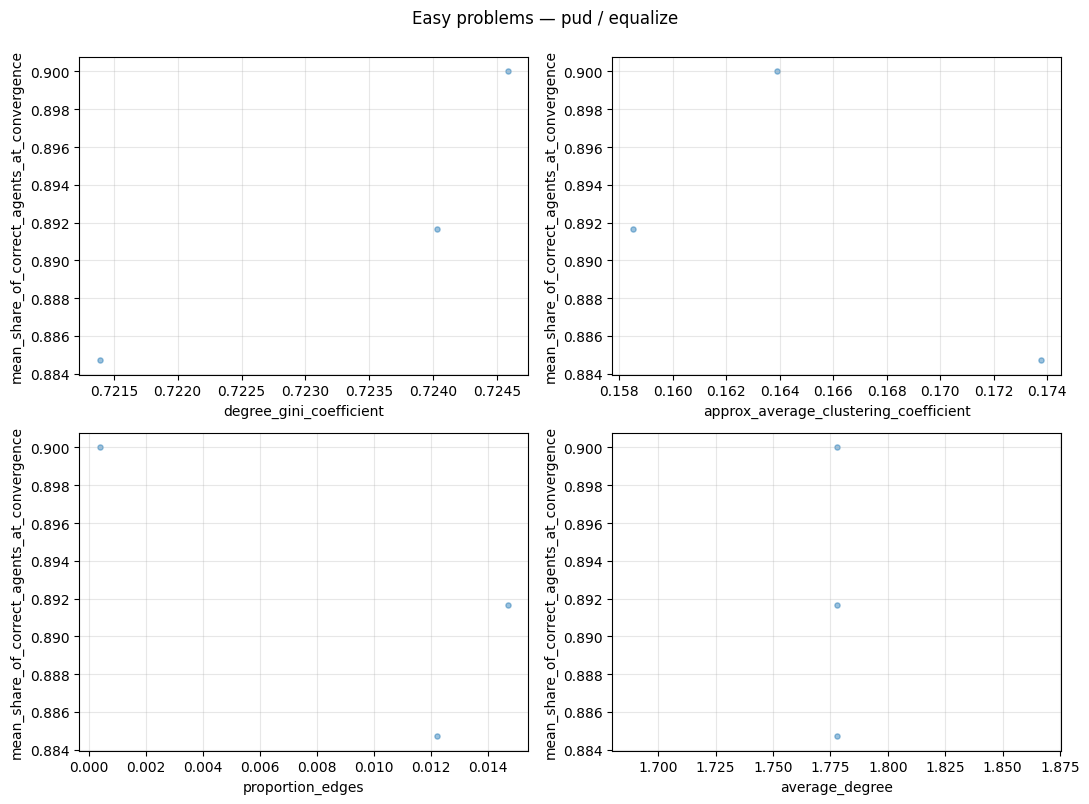

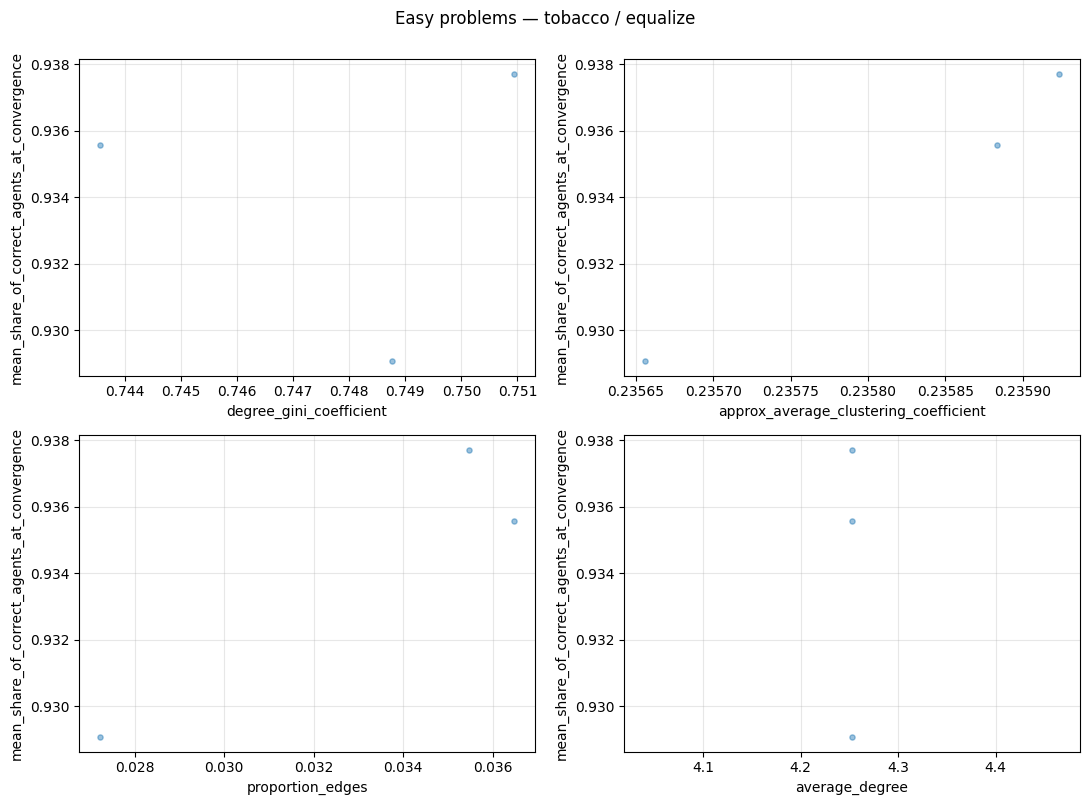

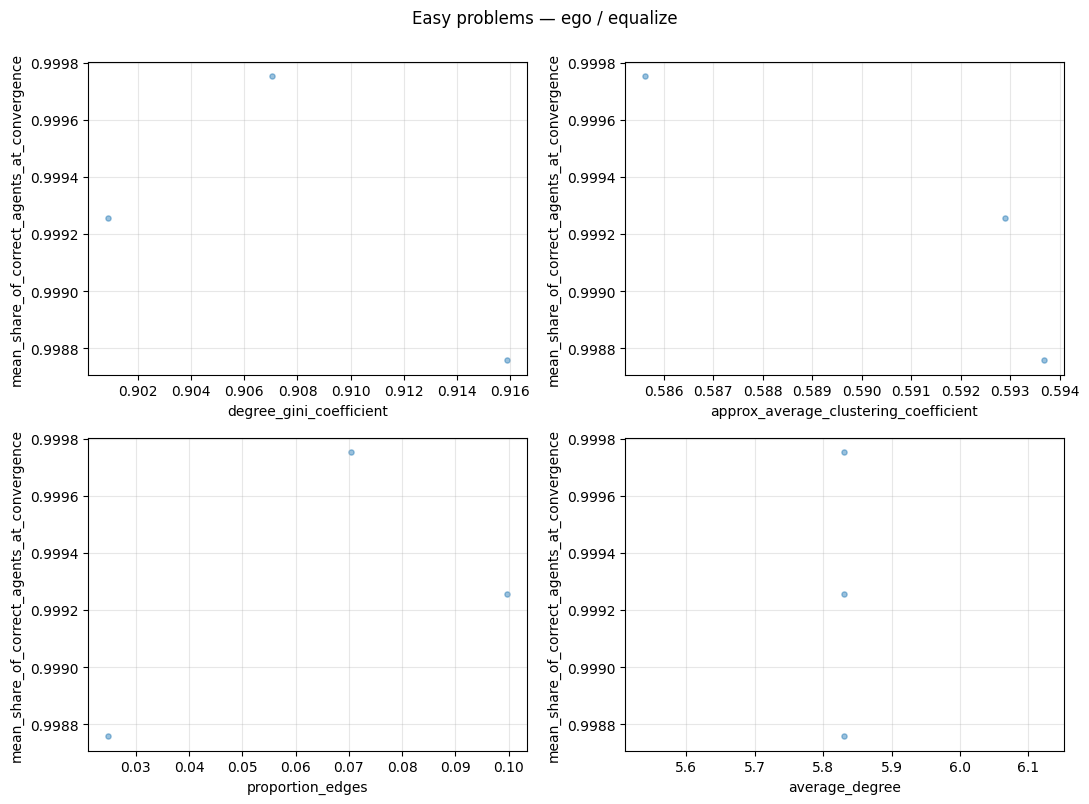

  Saved: results/equality_study/easy/smoke/runtime_projection.csv (3 rows)


In [8]:
if __name__ == "__main__":          # see "Running as a script" at the top
    RESULTS['easy'] = run_uncertainty_study(
        option_slug  = 'easy',
        option_title = 'Easy problems',
        uncertainty  = 0.1,
        master_seed  = 20260722,
        **FIXED,
    )

### Moderate problems


Moderate problems   [moderate]
  uncertainty=0.01  window=50  max_steps=2,000  master_seed=20260723
  3 variants x 8 runs x 3 arms = 72 model runs
  Results: results/equality_study/moderate/smoke
  Cache:   .variant_cache/moderate/smoke
  New study — configuration stamped.

Phase A — building variants
  [pud/equalize] 3 variants requested, 0 already cached, 3 to build


[pud/equalize] build: 100%|██████████| 3/3 [00:00<00:00,  4.22variant/s]

  [tobacco/equalize] 3 variants requested, 0 already cached, 3 to build



[tobacco/equalize] build: 100%|██████████| 3/3 [00:00<00:00,  3.32variant/s]

  [ego/equalize] 3 variants requested, 0 already cached, 3 to build


...

  [tobacco/equalize] 3 variants requested, 0 already on disk, 3 to run (24 simulations)


[tobacco/equalize]: 100%|██████████| 3/3 [00:02<00:00,  1.27variant/s, build=0.0s, run=0.8s]


  [ego/equalize] 3 variants requested, 0 already on disk, 3 to run (24 simulations)


[ego/equalize]: 100%|██████████| 3/3 [00:02<00:00,  1.30variant/s, build=0.0s, run=0.8s]


  phase B took 7s
  Saved: results/equality_study/moderate/smoke/cost_all_arms.csv (9 rows)

Progress
Progress report — results/equality_study/moderate/smoke
  72 / 72 simulations  (100.0% of goal)
  9 / 9 variants   |   arms complete: 3/3
  [########################################]
  STATUS: DONE — every arm has reached n_variants.
  Saved: results/equality_study/moderate/smoke/progress_report.csv (3 rows)
Parameter coverage — 9 of 9 planned variants banked
  proportion_edges: planned [0.00574196, 0.0929249]
    banked [0.00574196, 0.0929249]  quartile occupancy [2, 2, 3, 2]
  Saved: results/equality_study/moderate/smoke/parameter_coverage.csv (9 rows)

Validation
  [pud_equalize] 3 variants x 8 replicates
  [pud_equalize] OK — seeds distinct and every variant varies across replicates
  [tobacco_equalize] 3 variants x 8 replicates
  [tobacco_equalize] OK — seeds distinct and every variant varies across replicates
  [ego_equalize] 3 variants x 8 replicates
  [ego_equalize] OK — seeds 

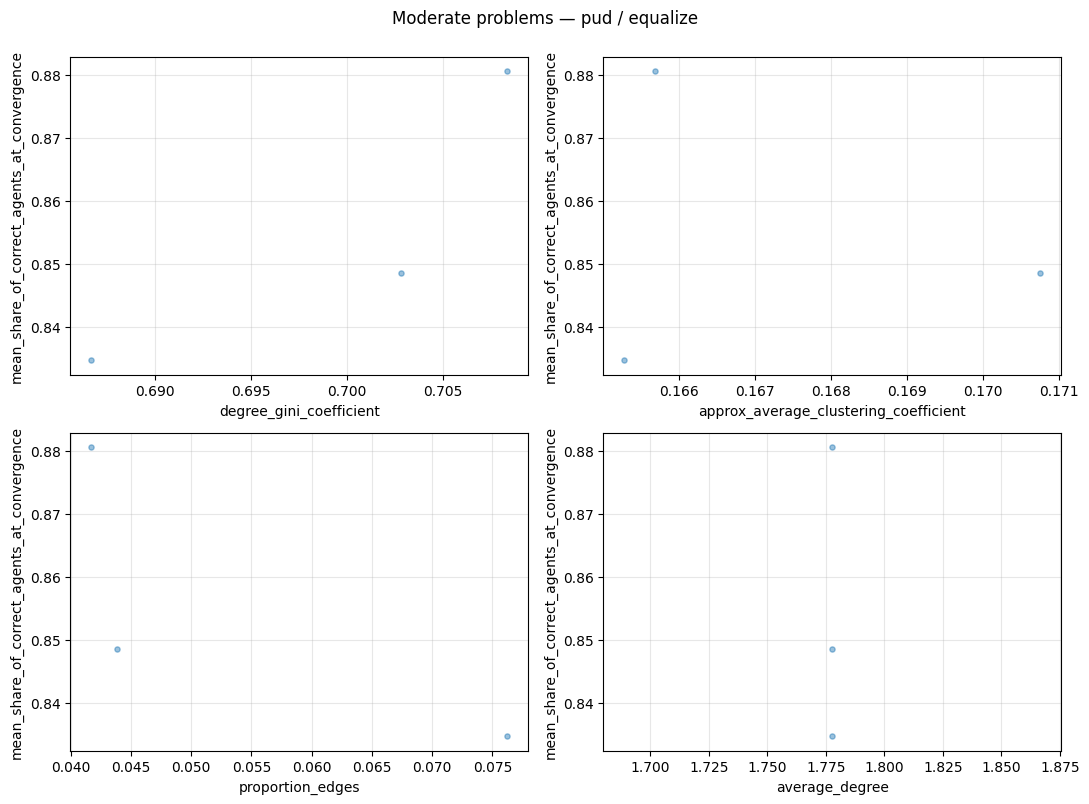

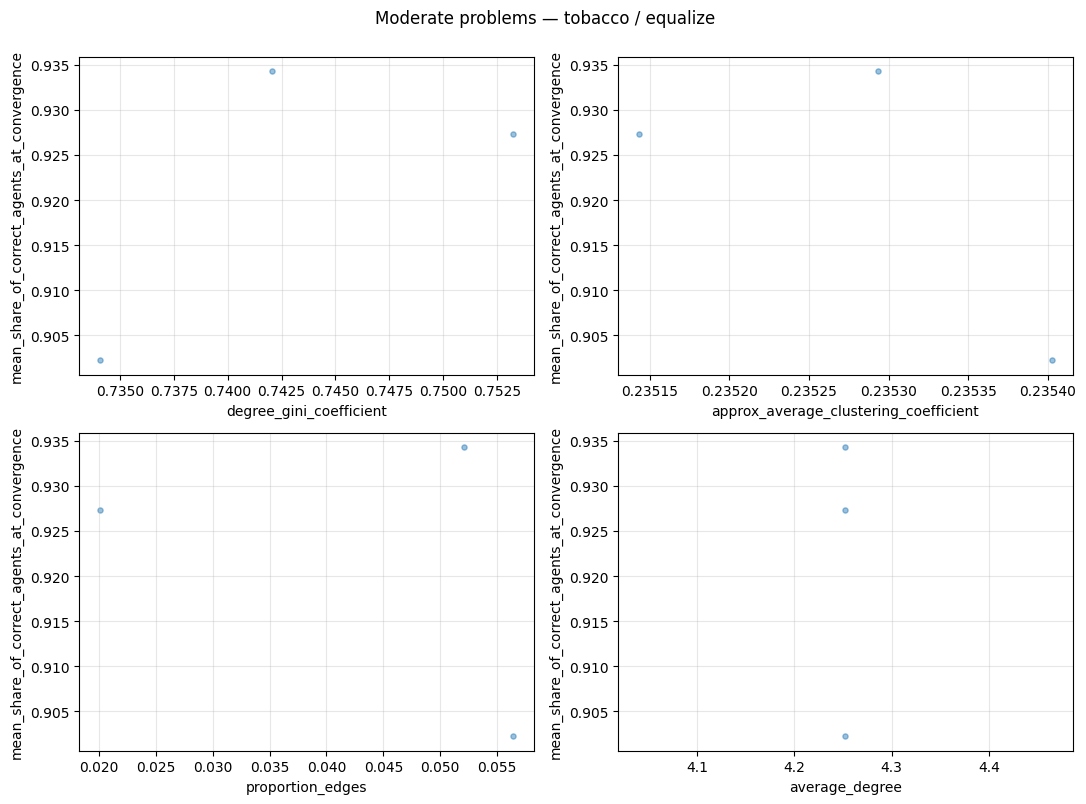

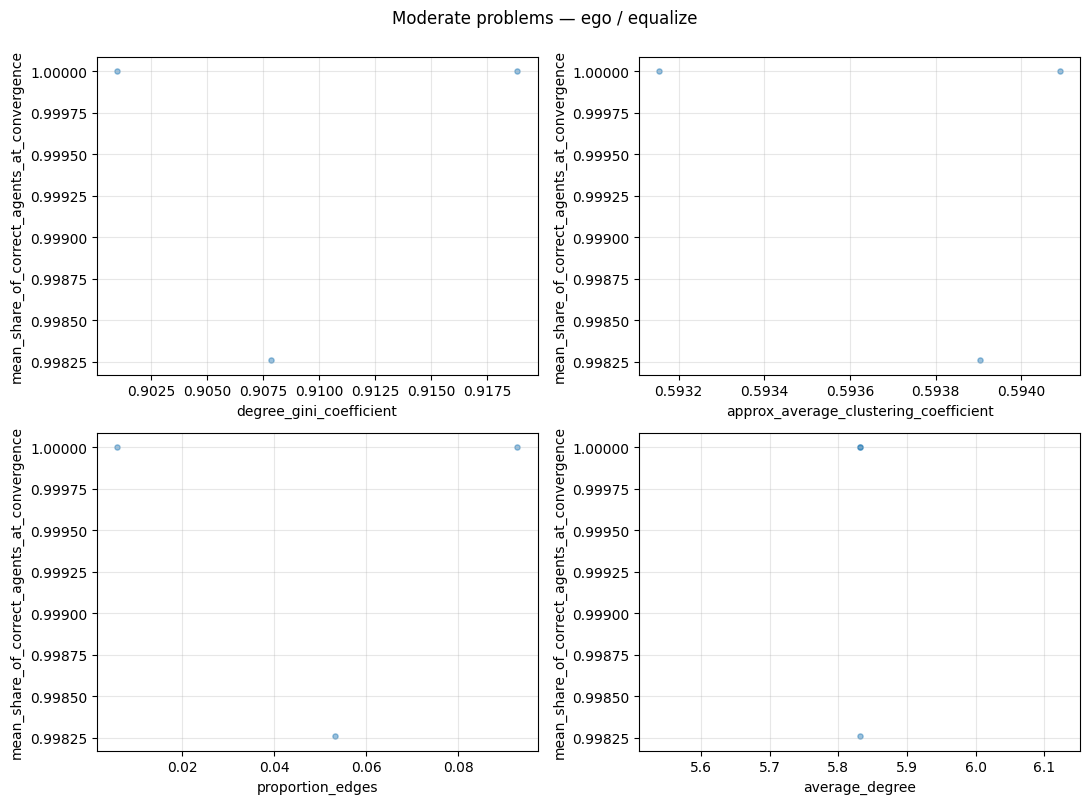

  Saved: results/equality_study/moderate/smoke/runtime_projection.csv (3 rows)


In [9]:
if __name__ == "__main__":          # see "Running as a script" at the top
    RESULTS['moderate'] = run_uncertainty_study(
        option_slug  = 'moderate',
        option_title = 'Moderate problems',
        uncertainty  = 0.01,
        master_seed  = 20260723,
        **FIXED,
    )

### Hard problems


Hard problems   [hard]
  uncertainty=0.001  window=50  max_steps=2,000  master_seed=20260724
  3 variants x 8 runs x 3 arms = 72 model runs
  Results: results/equality_study/hard/smoke
  Cache:   .variant_cache/hard/smoke
  New study — configuration stamped.

Phase A — building variants
  [pud/equalize] 3 variants requested, 0 already cached, 3 to build


[pud/equalize] build: 100%|██████████| 3/3 [00:00<00:00,  4.19variant/s]

  [tobacco/equalize] 3 variants requested, 0 already cached, 3 to build



[tobacco/equalize] build: 100%|██████████| 3/3 [00:01<00:00,  2.86variant/s]

  [ego/equalize] 3 variants requested, 0 already cached, 3 to build


...

  [tobacco/equalize] 3 variants requested, 0 already on disk, 3 to run (24 simulations)


[tobacco/equalize]: 100%|██████████| 3/3 [00:02<00:00,  1.18variant/s, build=0.0s, run=0.8s]


  [ego/equalize] 3 variants requested, 0 already on disk, 3 to run (24 simulations)


[ego/equalize]: 100%|██████████| 3/3 [00:02<00:00,  1.13variant/s, build=0.0s, run=0.9s]


  phase B took 8s
  Saved: results/equality_study/hard/smoke/cost_all_arms.csv (9 rows)

Progress
Progress report — results/equality_study/hard/smoke
  72 / 72 simulations  (100.0% of goal)
  9 / 9 variants   |   arms complete: 3/3
  [########################################]
  STATUS: DONE — every arm has reached n_variants.
  Saved: results/equality_study/hard/smoke/progress_report.csv (3 rows)
Parameter coverage — 9 of 9 planned variants banked
  proportion_edges: planned [0.0019072, 0.0819354]
    banked [0.0019072, 0.0819354]  quartile occupancy [3, 0, 4, 2]
  Saved: results/equality_study/hard/smoke/parameter_coverage.csv (9 rows)

Validation
  [pud_equalize] 3 variants x 8 replicates
  [pud_equalize] OK — seeds distinct and every variant varies across replicates
  [tobacco_equalize] 3 variants x 8 replicates
  [tobacco_equalize] OK — seeds distinct and every variant varies across replicates
  [ego_equalize] 3 variants x 8 replicates
  [ego_equalize] OK — seeds distinct and every

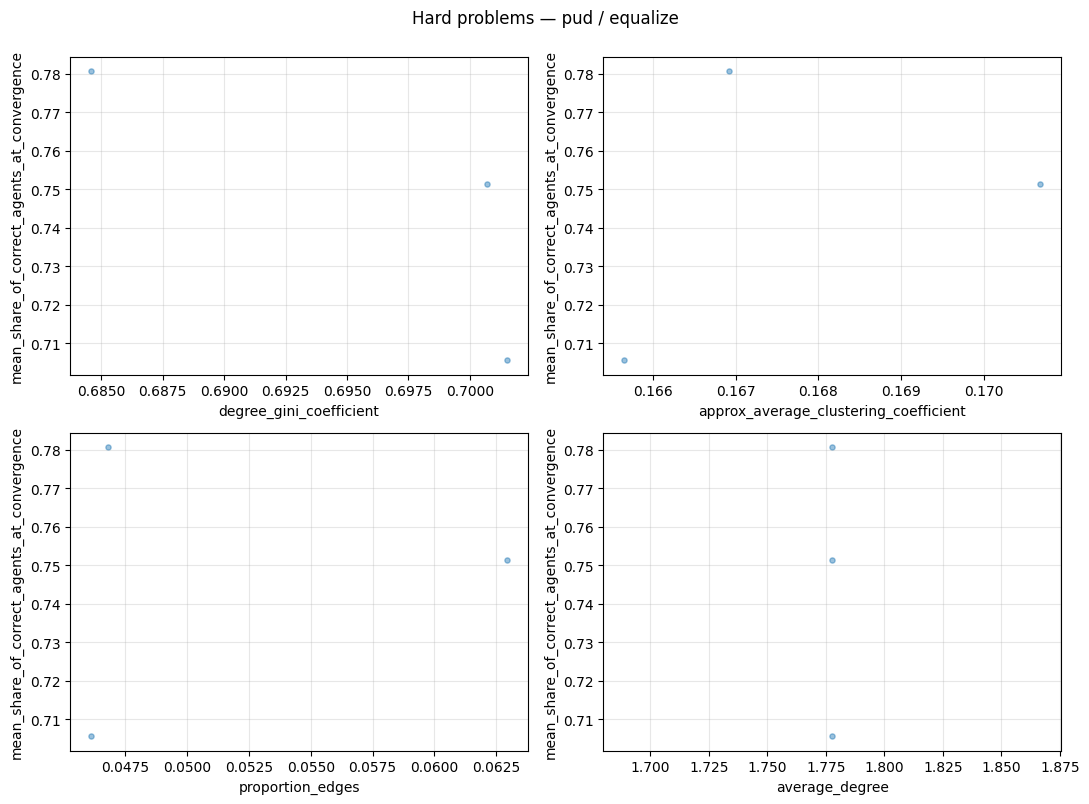

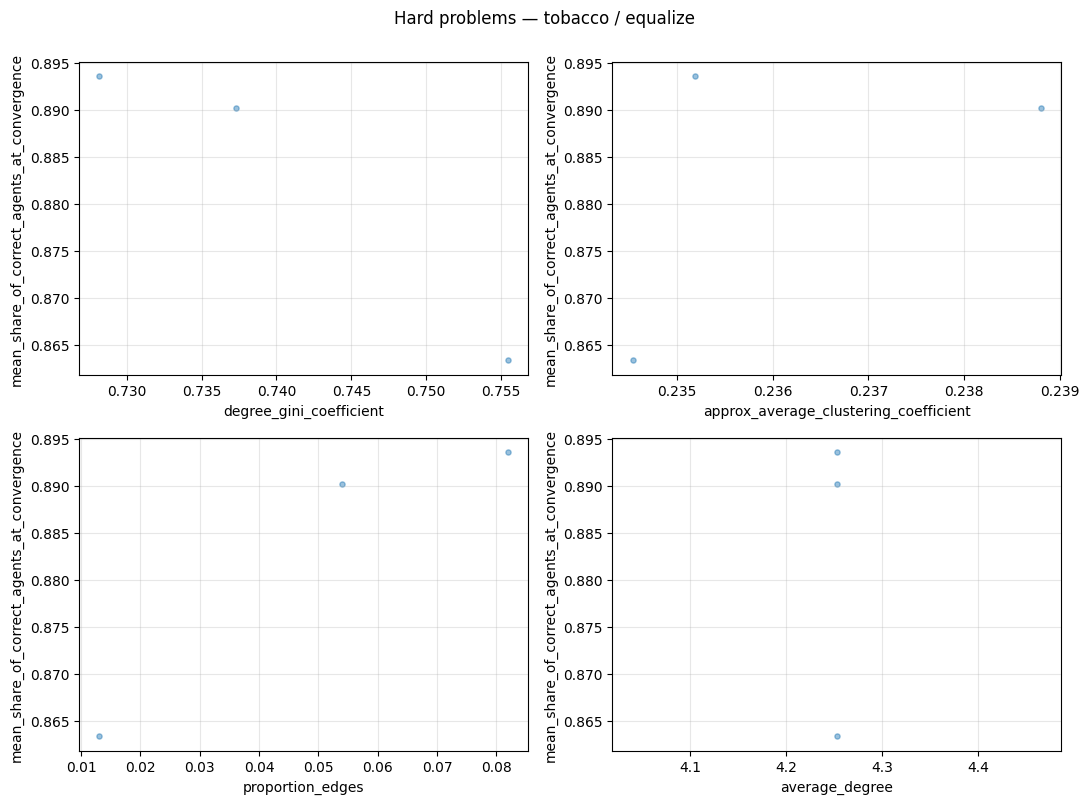

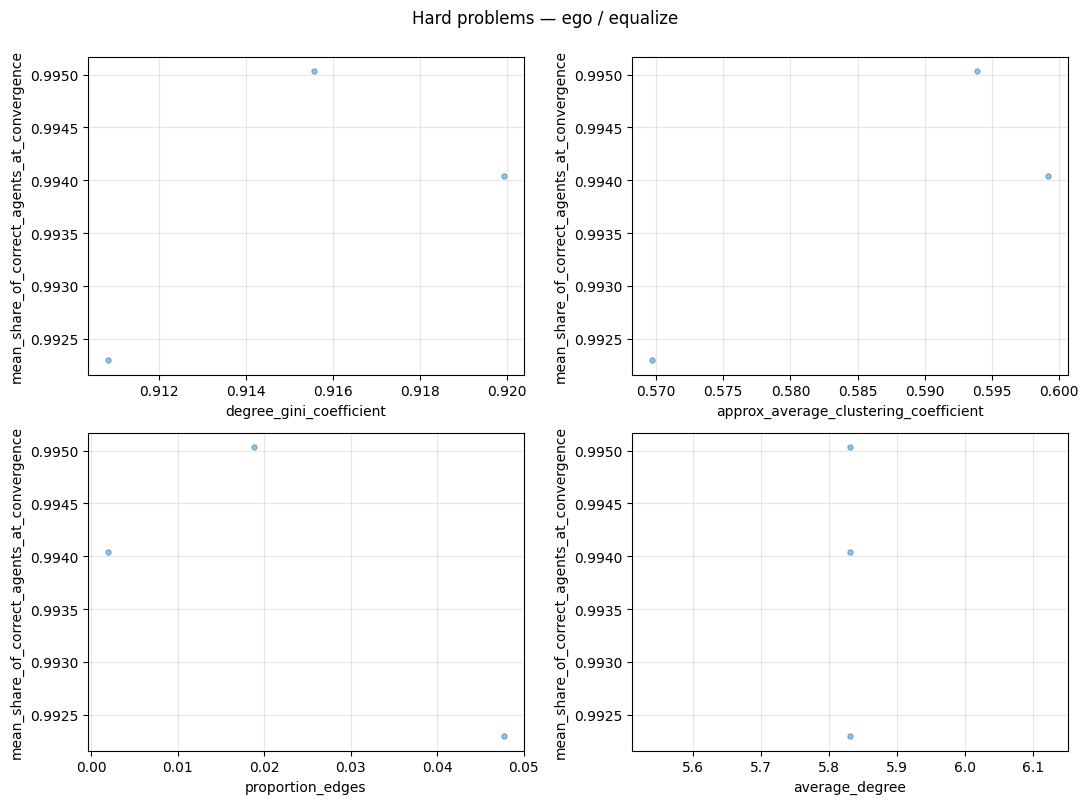

  Saved: results/equality_study/hard/smoke/runtime_projection.csv (3 rows)


In [10]:
if __name__ == "__main__":          # see "Running as a script" at the top
    RESULTS['hard'] = run_uncertainty_study(
        option_slug  = 'hard',
        option_title = 'Hard problems',
        uncertainty  = 0.001,
        master_seed  = 20260724,
        **FIXED,
    )

### Super hard problems

The hardest problem in the sweep: agents struggle to separate the two theories, so runs are long and can approach `MAX_STEPS`. Budget the sweep on this cell.


Super hard problems   [super_hard]
  uncertainty=0.0001  window=50  max_steps=2,000  master_seed=20260725
  3 variants x 8 runs x 3 arms = 72 model runs
  Results: results/equality_study/super_hard/smoke
  Cache:   .variant_cache/super_hard/smoke
  New study — configuration stamped.

Phase A — building variants
  [pud/equalize] 3 variants requested, 0 already cached, 3 to build


[pud/equalize] build: 100%|██████████| 3/3 [00:00<00:00,  4.12variant/s]

  [tobacco/equalize] 3 variants requested, 0 already cached, 3 to build



[tobacco/equalize] build: 100%|██████████| 3/3 [00:00<00:00,  3.35variant/s]

  [ego/equalize] 3 variants requested, 0 already cached, 3 to build


...

  [tobacco/equalize] 3 variants requested, 0 already on disk, 3 to run (24 simulations)


[tobacco/equalize]: 100%|██████████| 3/3 [00:02<00:00,  1.10variant/s, build=0.0s, run=0.9s]


  [ego/equalize] 3 variants requested, 0 already on disk, 3 to run (24 simulations)


[ego/equalize]: 100%|██████████| 3/3 [00:02<00:00,  1.06variant/s, build=0.0s, run=1.0s]


  phase B took 8s
  Saved: results/equality_study/super_hard/smoke/cost_all_arms.csv (9 rows)

Progress
Progress report — results/equality_study/super_hard/smoke
  72 / 72 simulations  (100.0% of goal)
  9 / 9 variants   |   arms complete: 3/3
  [########################################]
  STATUS: DONE — every arm has reached n_variants.
  Saved: results/equality_study/super_hard/smoke/progress_report.csv (3 rows)
Parameter coverage — 9 of 9 planned variants banked
  proportion_edges: planned [0.00285877, 0.0998194]
    banked [0.00285877, 0.0998194]  quartile occupancy [4, 3, 1, 1]
  Saved: results/equality_study/super_hard/smoke/parameter_coverage.csv (9 rows)

Validation
  [pud_equalize] 3 variants x 8 replicates
  [pud_equalize] OK — seeds distinct and every variant varies across replicates
  [tobacco_equalize] 3 variants x 8 replicates
  [tobacco_equalize] OK — seeds distinct and every variant varies across replicates
  [ego_equalize] 3 variants x 8 replicates
  [ego_equalize] OK 

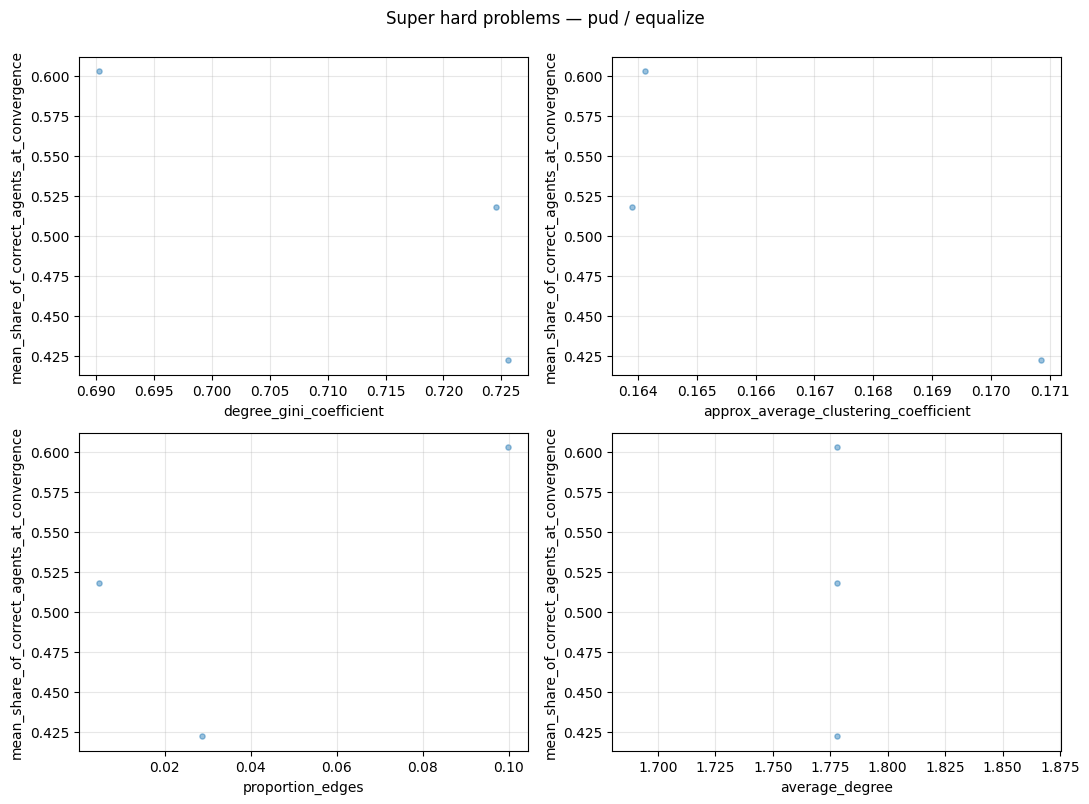

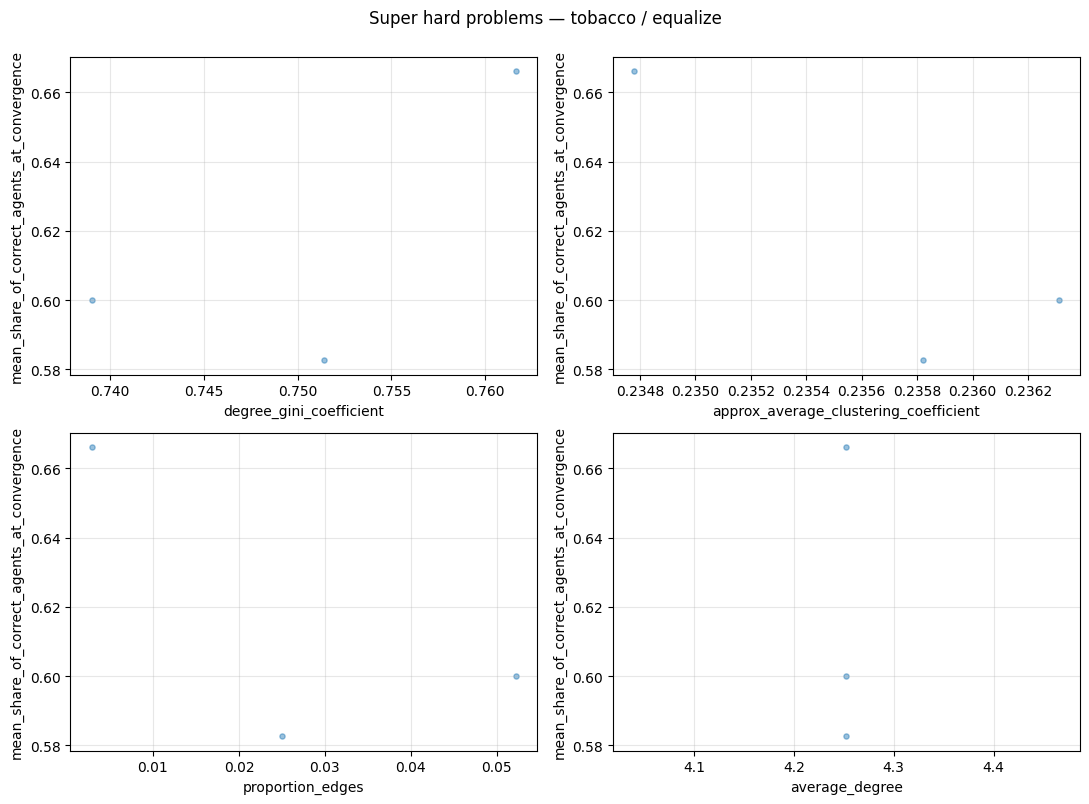

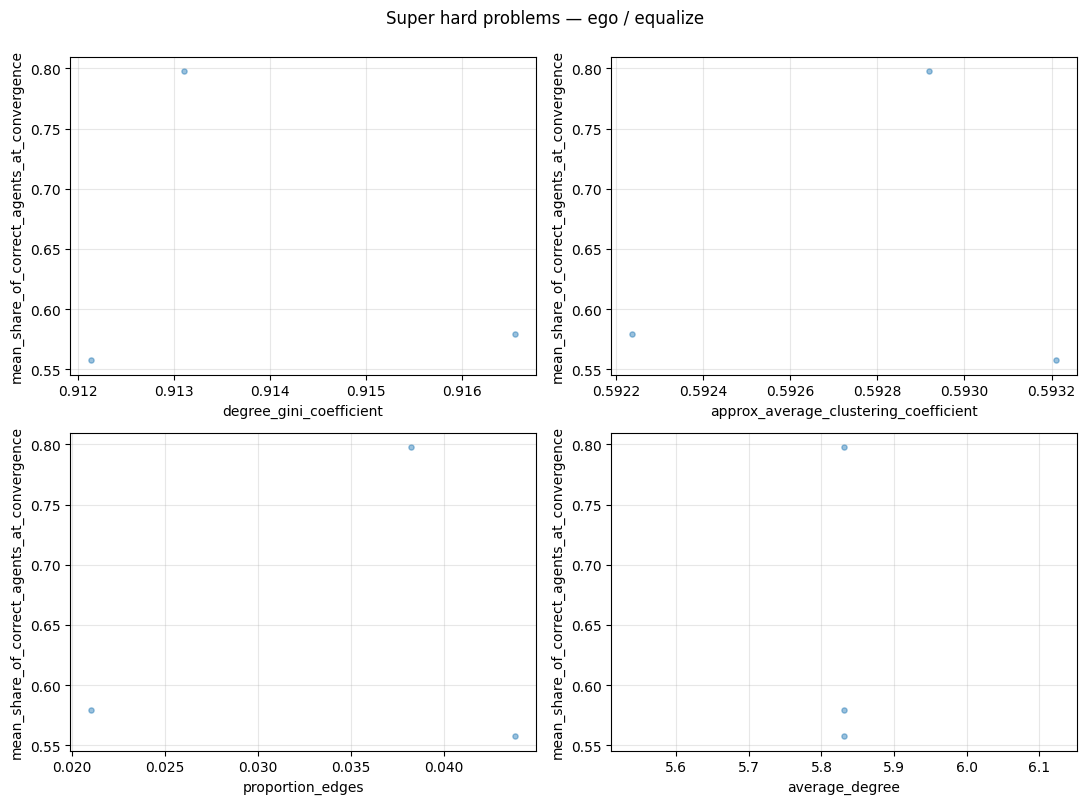

  Saved: results/equality_study/super_hard/smoke/runtime_projection.csv (3 rows)


In [11]:
if __name__ == "__main__":          # see "Running as a script" at the top
    RESULTS['super_hard'] = run_uncertainty_study(
        option_slug  = 'super_hard',
        option_title = 'Super hard problems',
        uncertainty  = 0.0001,
        master_seed  = 20260725,
        **FIXED,
    )

# Session report

What this session actually banked, across every study run above. Safe to run after a
partial sweep — studies not run simply do not appear.

In [12]:
if __name__ == "__main__" and RESULTS:
    overview = pd.DataFrame([
        {
            'study': r['title'],
            'slug': r['slug'],
            'uncertainty': r['uncertainty'],
            'master_seed': r['master_seed'],
            'variants_done': int(r['report']['variants_done'].sum()) if len(r['report']) else 0,
            'variants_target': int(r['report']['variants_target'].sum()) if len(r['report']) else 0,
            'sims_done': int(r['report']['sims_done'].sum()) if len(r['report']) else 0,
            'arms_complete': int((r['report']['status'] == 'complete').sum()) if len(r['report']) else 0,
            'summary_rows': len(r['summary']),
            'build_sec': round(r['build_sec'], 1),
            'run_sec': round(r['run_sec'], 1),
        }
        for r in RESULTS.values()
    ])
    display(overview)
elif __name__ == "__main__":
    print("No study has been run in this session.")

,study,slug,uncertainty,master_seed,variants_done,variants_target,sims_done,arms_complete,summary_rows,build_sec,run_sec
0,Easy problems,easy,0.1000,20260722,9,9,72,3,9,6.6,6.9
1,Moderate problems,moderate,0.0100,20260723,9,9,72,3,9,6.4,7.0
2,Hard problems,hard,0.0010,20260724,9,9,72,3,9,4.8,7.6
3,Super hard problems,super_hard,0.0001,20260725,9,9,72,3,9,4.3,8.0


# Disconnect from runtime

In [13]:
# Must be the LAST cell — after every save. `runtime.unassign()` actually frees the
# runtime, whereas `kernel.disconnect()` only detaches the frontend and leaves it
# assigned (and billed). Gated so a developer iterating interactively, or a script
# running locally, is not kicked out.
AUTO_DISCONNECT = True

if __name__ == "__main__" and AUTO_DISCONNECT and not RUNNING_LOCALLY:
    from datetime import datetime

    import pytz

    stamp = datetime.now(pytz.timezone('America/New_York')).strftime('%Y-%m-%d %H:%M:%S %Z')
    print(f"Finished at {stamp} — releasing runtime.")
    from google.colab import runtime
    runtime.unassign()
elif __name__ == "__main__":
    print("Run complete (runtime not released; set AUTO_DISCONNECT=True to free it).")

Run complete (runtime not released; set AUTO_DISCONNECT=True to free it).
